In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../data_derived/bars.csv")
OUT_DIR = Path("../reports/week1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()  #fixes trailing spaces if it exists

print("Columns:", df.columns.tolist()) #listing column headers

ts_col = "unix"
px_col = "close"

Columns: ['unix', 'date', 'symbol', 'open', 'high', 'low', 'close', 'Volume BTC', 'Volume USDT', 'tradecount']


In [10]:
df[ts_col] = pd.to_numeric(df[ts_col], errors="coerce")
df[px_col] = pd.to_numeric(df[px_col], errors="coerce")
df = df.dropna(subset=[ts_col, px_col])

# Detect seconds vs milliseconds safely
median_ts = df[ts_col].median()
unit = "ms" if median_ts > 1e11 else "s"

df["timestamp"] = pd.to_datetime(df[ts_col], unit=unit, utc=True)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").drop_duplicates(subset=["timestamp"])

df["ret"] = df[px_col].pct_change()
df["roll_vol"] = df["ret"].rolling(60).std()  # assumes minute bars; fine for Week 1

print("Detected timestamp unit:", unit)
print("Start:", df["timestamp"].min())
print("End:  ", df["timestamp"].max())
print("Rows: ", len(df))
print("Mean ret:", df["ret"].mean())
print("Std ret: ", df["ret"].std())

Detected timestamp unit: ms
Start: 2020-07-25 04:10:00+00:00
End:   2022-07-27 08:43:00+00:00
Rows:  1048574
Mean ret: 1.4329077783248125e-06
Std ret:  0.001154349251204766


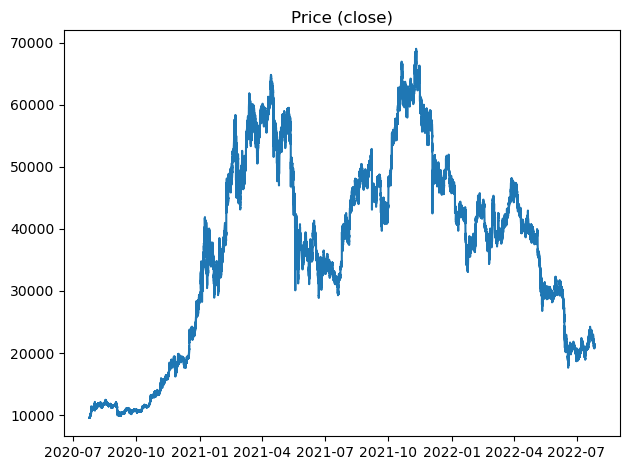

In [11]:
#price plot
plt.figure()
plt.plot(df["timestamp"], df[px_col])
plt.title("Price (close)")
plt.tight_layout()
plt.savefig(OUT_DIR / "price.png", dpi=150)
plt.show()

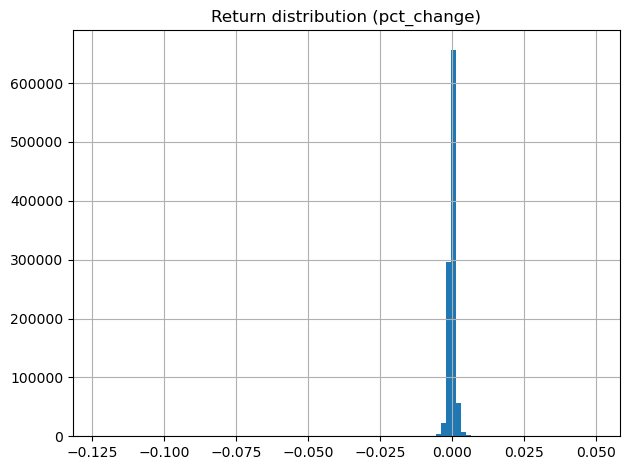

In [12]:
#histogram plot
plt.figure()
df["ret"].dropna().hist(bins=100)
plt.title("Return distribution (pct_change)")
plt.tight_layout()
plt.savefig(OUT_DIR / "returns_hist.png", dpi=150)
plt.show()

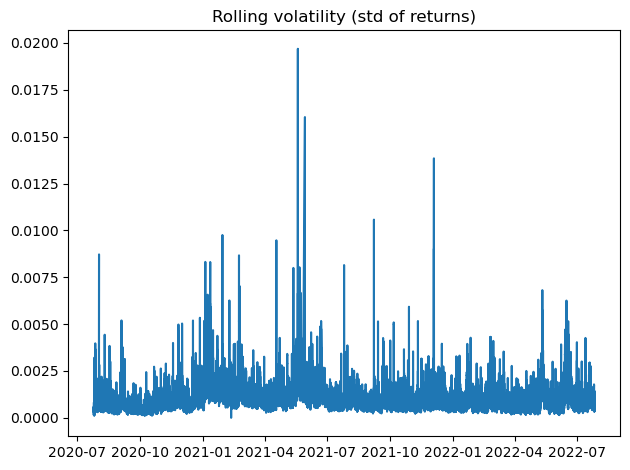

In [13]:
#rolling vol
plt.figure()
plt.plot(df["timestamp"], df["roll_vol"])
plt.title("Rolling volatility (std of returns)")
plt.tight_layout()
plt.savefig(OUT_DIR / "rolling_vol.png", dpi=150)
plt.show()